# PRUEBAS DE CLUSTERING APLICADO AL DATASET ELECTORAL LAPOP 2023

### INICIALIZACIÓN

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np

from src.clustering.traditional import KMedoids, HierarchicalClustering, DBSCAN
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

print("="*70)
print("TEST SIMPLE DE ALGORITMOS DE CLUSTERING")
print("="*70)

# Cargar dataset preprocesado
dataset_path = f"{PROCESSED_DATA_PATH}"
df = pd.read_csv(dataset_path)

print(f"\n✓ Dataset cargado:")
print(f"  Dimensiones: {df.shape[0]} registros × {df.shape[1]} variables")
print(f"  Missings: {df.isnull().sum().sum()}")
print(f"\nPrimeras 3 filas:")
print(df.head(3))
print("="*70)

TEST SIMPLE DE ALGORITMOS DE CLUSTERING

✓ Dataset cargado:
  Dimensiones: 1706 registros × 28 variables
  Missings: 0

Primeras 3 filas:
       edre    q10inc  etid  boletidnew  boletidnewb  estratopri   ur  \
0  1.000000  0.000000   0.2         1.0     0.142857         0.0  1.0   
1  0.166667  0.285714   0.2         0.0     0.000000         0.0  1.0   
2  0.500000  0.571429   0.2         1.0     0.000000         0.0  1.0   

    ocupoit        q2  q1tc_r  ...  estratosec  q12cn  q12bn  gi0n  smedia3n  \
0  0.555556  0.485714     0.5  ...         0.0  0.000    0.0   0.0      0.00   
1  0.777778  0.528571     0.0  ...         0.0  0.250    0.3   0.0      0.75   
2  1.000000  0.185714     0.0  ...         1.0  0.375    0.3   0.0      0.75   

   q10e  q11n  leng4  wealth_index  civic_index  
0   0.5   0.0   0.25           0.6     0.416667  
1   1.0   0.2   0.25           0.7     0.000000  
2   1.0   0.4   0.50           0.6     0.416667  

[3 rows x 28 columns]


### APLICACIÓN DE LOS ALGORITMOS

##### K-MEDOIDS


In [2]:
print("\n--- BÚSQUEDA DE CONFIGURACIÓN - K-MEDOIDS ---\n")

k_range = range(2, 24)  # Limitado a 11 de acuerdo a la regla de Sturges k_max = 1 + log₂(n) → con n=1706 → k ≈ 11
resultados_k = []

for k in k_range:
    km_temp = KMedoids(n_clusters=k, random_state=42)
    km_temp.fit(df)
    metrics_temp = calculate_metrics(df, km_temp.labels_)
    resultados_k.append({
        'k': k,
        'inercia': km_temp.inertia_,
        'silhouette': metrics_temp['silhouette'],
        'davies_bouldin': metrics_temp['davies_bouldin']
    })
    print(f"  k={k}: Inercia={km_temp.inertia_:.2f} | "
          f"Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

# Criterio compuesto: normalizar ambas métricas y combinarlas
# Silhouette: mayor es mejor → normalizar y maximizar
# Davies-Bouldin: menor es mejor → invertir, normalizar y maximizar
sil_vals = np.array([r['silhouette'] for r in resultados_k])
db_vals  = np.array([r['davies_bouldin'] for r in resultados_k])

sil_norm = (sil_vals - sil_vals.min()) / (sil_vals.max() - sil_vals.min())
db_norm  = 1 - (db_vals - db_vals.min()) / (db_vals.max() - db_vals.min())

score_combinado = 0.6 * sil_norm + 0.4 * db_norm  # silhouette pesa más

mejor_idx = np.argmax(score_combinado)
k_optimo  = resultados_k[mejor_idx]['k']

print(f"\n  k óptimo por Silhouette:       k={resultados_k[np.argmax(sil_vals)]['k']}")
print(f"  k óptimo por Davies-Bouldin:   k={resultados_k[np.argmin(db_vals)]['k']}")
print(f"  k óptimo por criterio compuesto (60% Sil + 40% DB): k={k_optimo}")


--- BÚSQUEDA DE CONFIGURACIÓN - K-MEDOIDS ---

Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 8921.1829
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1170
  ✓ Davies-Bouldin Index: 2.6933
  ✓ Calinski-Harabasz Index: 224.9953
  k=2: Inercia=8921.18 | Sil=0.1170 | DB=2.6933
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 8314.3829
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0817
  ✓ Davies-Bouldin Index: 2.8913
  ✓ Calinski-Harabasz Index: 171.7734
  k=3: Inercia=8314.38 | Sil=0.0817 | DB=2.8913
Entrenando K-Medoids con 4 clusters...
✓ K-Medoids entrenado: 4 clusters identificados
  Inercia: 7930.2754
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0699
  ✓ Davies-Bouldin Index: 3.0507
  ✓ Calinski-Harabasz Index: 132.6730
  k=4: Inercia=7930.28 | Sil

In [3]:
print("\n--- TEST K-MEDOIDS ---\n")

# Entrenar con k óptimo
k_final = int(k_optimo)
print(f"\nEntrenando con k={k_final}...")
kmedoids = KMedoids(n_clusters=k_final, random_state=42)
kmedoids.fit(df)

# Distribución y métricas
print("\nDistribución:")
print(kmedoids.get_cluster_distribution())
print("\nMétricas:")
metrics_km = calculate_metrics(df, kmedoids.labels_)

print("="*70)


--- TEST K-MEDOIDS ---


Entrenando con k=2...
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 8921.1829

Distribución:
   cluster  size  percentage
0        0   987   57.854631
1        1   719   42.145369

Métricas:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1170
  ✓ Davies-Bouldin Index: 2.6933
  ✓ Calinski-Harabasz Index: 224.9953


##### CLUSTERING JERARQUICO

In [ ]:
print("\n--- BÚSQUEDA DE CONFIGURACIÓN - CLUSTERING JERÁRQUICO ---\n")

# Evaluar linkages con múltiples n_clusters para encontrar el menor metodo
n_clusters_eval = [2, 3, 4, 5, 6, 7, 8, 9, 10]
linkage_methods  = ['ward', 'complete', 'average', 'single']
resultados_linkage = []

print("Comparando linkages (promedio de silhouette para n=3,4,5):")
for linkage in linkage_methods:
    sils = []
    for n in n_clusters_eval:
        hc_temp = HierarchicalClustering(n_clusters=n, linkage=linkage)
        hc_temp.fit(df)
        metrics_temp = calculate_metrics(df, hc_temp.labels_)
        # Solo contar si no hay clusters degenerados (menos del 1% del total)
        sizes = pd.Series(hc_temp.labels_).value_counts()
        if sizes.min() >= len(df) * 0.01:
            sils.append(metrics_temp['silhouette'])
    sil_prom = np.mean(sils) if sils else -1
    resultados_linkage.append({'linkage': linkage, 'silhouette_promedio': sil_prom})
    print(f"  {linkage:10s}: Sil promedio={sil_prom:.4f} "
          f"({'descartado por desbalance' if sil_prom == -1 else ''})")

mejor_linkage = max(resultados_linkage, key=lambda x: x['silhouette_promedio'])['linkage']
print(f"\n  Mejor linkage: '{mejor_linkage}'")

# Buscar n_clusters óptimo con el mejor linkage
print(f"\nBuscando n_clusters óptimo con linkage='{mejor_linkage}'...")
resultados_n = []
for n in range(2, 12):
    hc_temp = HierarchicalClustering(n_clusters=n, linkage=mejor_linkage)
    hc_temp.fit(df)
    sizes   = pd.Series(hc_temp.labels_).value_counts()
    # Descartar si hay cluster con menos del 1% de los datos
    if sizes.min() < len(df) * 0.01:
        print(f"  n={n}: descartado (cluster degenerado: {sizes.min()} puntos)")
        continue
    metrics_temp = calculate_metrics(df, hc_temp.labels_)
    resultados_n.append({'n': n, 'silhouette': metrics_temp['silhouette'],
                         'davies_bouldin': metrics_temp['davies_bouldin']})
    print(f"  n={n}: Sil={metrics_temp['silhouette']:.4f} | "
          f"DB={metrics_temp['davies_bouldin']:.4f}")

n_optimo = max(resultados_n, key=lambda x: x['silhouette'])['n'] if resultados_n else 3
print(f"\n  n_clusters óptimo: {n_optimo}")

print(f"\n === CONFIGURACION OPTIMA === ")
print(f" Mejor linkage: '{mejor_linkage}'")
print(f" n_clusters óptimo: {n_optimo}")


--- BÚSQUEDA DE CONFIGURACIÓN - CLUSTERING JERÁRQUICO ---

Comparando linkages (promedio de silhouette para n=3,4,5):
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0971
  ✓ Davies-Bouldin Index: 2.9127
  ✓ Calinski-Harabasz Index: 192.4590
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 4
  ✓ Silhouette Score: 0.0725
  ✓ Davies-Bouldin Index: 2.7063
  ✓ Calinski-Harabasz Index: 158.3615
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 5 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 5
  ✓ Silhouette Score: 0.0692
  ✓ Davies-Bouldin Index: 2.3932
  ✓ Calinski-Harabasz Index: 141.2703
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 6 clusters
Calculando métricas d

In [46]:
print("\n--- TEST CLUSTERING JERÁRQUICO ---\n")

# Entrenar con los parámetros encontrados
print(f"\nPaso 3: Entrenando con n_clusters={n_optimo}, linkage='{mejor_linkage}'...")
hierarchical = HierarchicalClustering(n_clusters=n_optimo, linkage=mejor_linkage)
hierarchical.fit(df)

print("\nDistribución:")
print(hierarchical.get_cluster_distribution())
print("\nMétricas finales:")
metrics_hc = calculate_metrics(df, hierarchical.labels_)

print("="*70)


--- TEST CLUSTERING JERÁRQUICO ---


Paso 3: Entrenando con n_clusters=2, linkage='ward'...
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 2 clusters

Distribución:
   cluster  size  percentage
0        0  1109   65.005862
1        1   597   34.994138

Métricas finales:
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1452
  ✓ Davies-Bouldin Index: 2.3441
  ✓ Calinski-Harabasz Index: 274.2366



--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---

✓ Dendrograma guardado en: ../../figures/dendrograma_completo.png


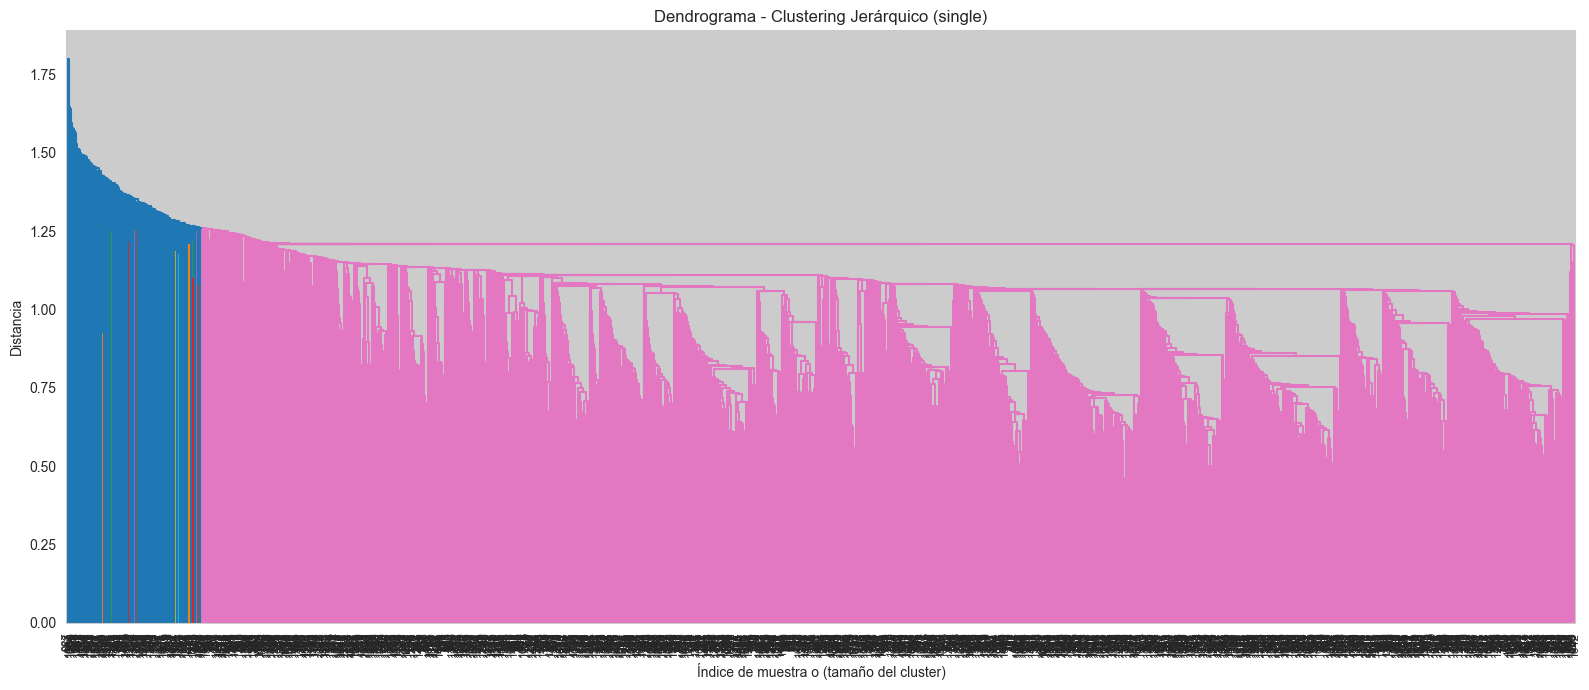

✓ Dendrograma guardado en: ../../figures/dendrograma_truncado.png


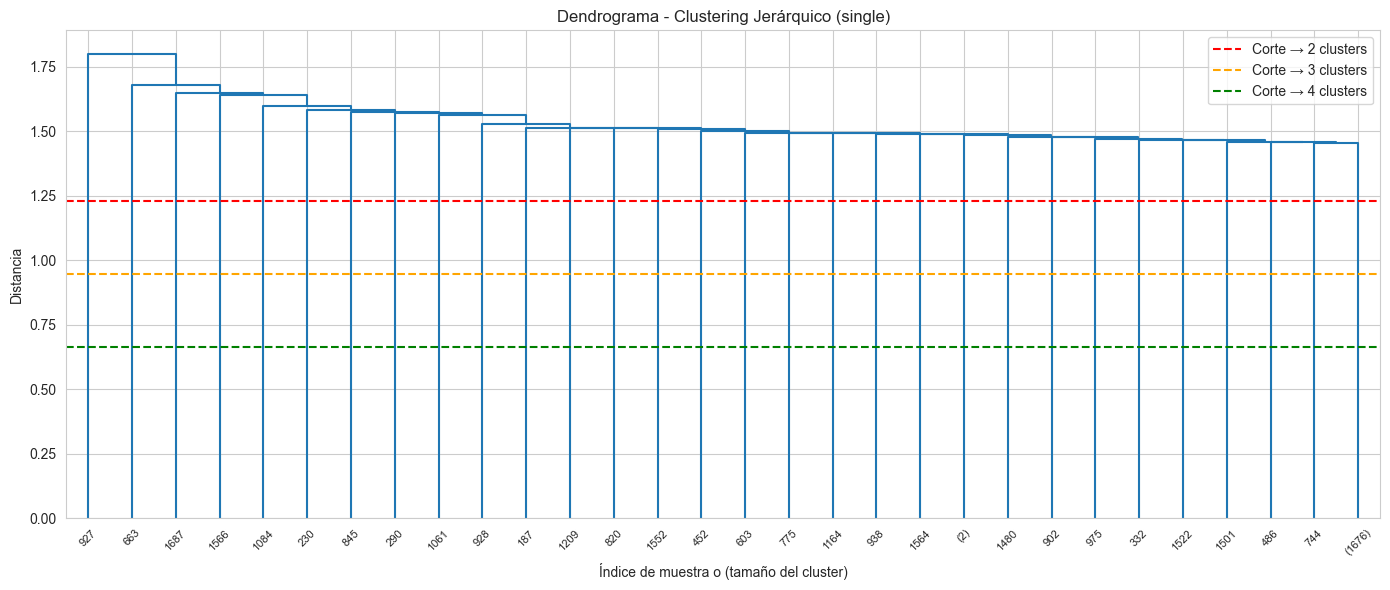


Interpretación:
  Linkage usado: single
  n_clusters actual: 2
  Silhouette: 0.1837

  Las líneas de corte muestran dónde cortar el dendrograma
  para obtener 2, 3 o 4 clusters.
  Los saltos grandes en altura = clusters naturales en los datos.


In [38]:
print("\n--- DENDROGRAMA - CLUSTERING JERÁRQUICO ---\n")

fig1 = hierarchical.plot_dendrogram(
    figsize=(16, 7),
    truncate_mode=None,
    save_path='../../figures/dendrograma_completo.png'
)
plt.show()

fig2 = hierarchical.plot_dendrogram(
    figsize=(14, 6),
    truncate_mode='lastp',
    p=30,
    save_path='../../figures/dendrograma_truncado.png'
)

ax = plt.gca()
colores = ['red', 'orange', 'green']
alturas = [0.65, 0.50, 0.35] 

for altura, color, n in zip(alturas, colores, [2, 3, 4]):
    ax.axhline(
        y=altura * ax.get_ylim()[1],
        color=color,
        linestyle='--',
        linewidth=1.5,
        label=f'Corte → {n} clusters'
    )

ax.legend(loc='upper right')
plt.show()

print("\nInterpretación:")
print(f"  Linkage usado: {hierarchical.linkage}")
print(f"  n_clusters actual: {hierarchical.n_clusters_}")
print(f"  Silhouette: {metrics_hc['silhouette']:.4f}")
print("\n  Las líneas de corte muestran dónde cortar el dendrograma")
print("  para obtener 2, 3 o 4 clusters.")
print("  Los saltos grandes en altura = clusters naturales en los datos.")

In [48]:
from sklearn.decomposition import PCA
import pandas as pd

print("\n--- PCA PARA DBSCAN ---\n")

pca = PCA(n_components=0.90, random_state=42)
df_pca_array = pca.fit_transform(df)

df_pca = pd.DataFrame(
    df_pca_array,
    columns=[f"PCA_{i+1}" for i in range(df_pca_array.shape[1])]
)

print(f"Dimensiones originales: {df.shape[1]}")
print(f"Dimensiones PCA: {df_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}")



--- PCA PARA DBSCAN ---

Dimensiones originales: 27
Dimensiones PCA: 17
Varianza explicada: 0.9022



--- BUSQUEDA DE CONFIGURACIÓN - DBSCAN ---

ANÁLISIS DE PARÁMETROS DBSCAN
Dataset: 1706 muestras × 17 features

Regla empírica para min_samples (>= n_features = 17):
  k candidatos a explorar: [8, 17, 25, 34]

Codos detectados (eps candidatos por valor de k):
  k (min_samples)      eps en codo     interpretación
  -------------------------------------------------------
  k=8                  eps≈1.2651        conservador (más clusters, menos ruido)
  k=17                 eps≈1.3731        recomendado
  k=25                 eps≈1.3952        recomendado
  k=34                 eps≈1.4922        agresivo (menos clusters, más ruido)

✓ Gráfico guardado en: C:\electocluster\results/clustering/kdistance_plot.png


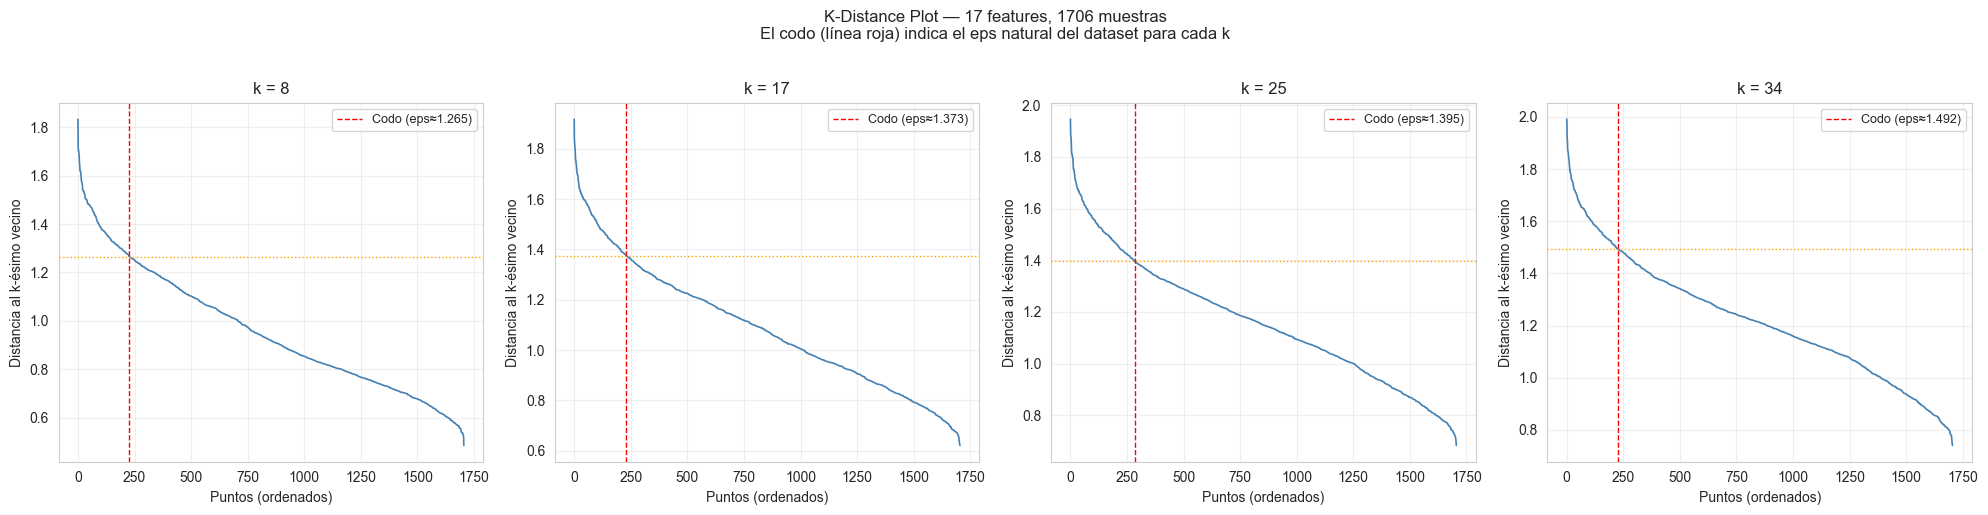


ESPACIO DE BÚSQUEDA RECOMENDADO
  eps:          [0.886, 1.062, 1.238, 1.414, 1.59, 1.766, 1.942]
  min_samples:  [8, 17, 25, 34]

  Combinaciones totales: 28

Eps candidatos por valor de k:
  k=8      eps_codo=1.2651     rango=[0.4847, 1.8342]
  k=17     eps_codo=1.3731     rango=[0.6212, 1.9179]
  k=25     eps_codo=1.3952     rango=[0.683, 1.946]
  k=34     eps_codo=1.4922     rango=[0.7405, 1.9916]

Espacio de búsqueda derivado:
  eps:         [0.886, 1.062, 1.238, 1.414, 1.59, 1.766, 1.942]
  min_samples: [8, 17, 25, 34]
  Combinaciones totales: 28


In [49]:
print("\n--- BUSQUEDA DE CONFIGURACIÓN - DBSCAN ---\n")

import matplotlib.pyplot as plt
from src.utils.params_search import analyze_dbscan_params, build_dbscan_configs
from src.utils.constants import RESULTS_PATH

analisis = analyze_dbscan_params(
    df_pca,
    output_path=f"{RESULTS_PATH}/clustering/kdistance_plot.png"
)

plt.show()

# Resultados del análisis
print("\nEps candidatos por valor de k:")
for k, datos in analisis['analisis_por_k'].items():
    print(f"  k={k:<6} eps_codo={datos['eps_codo']:<10} "
          f"rango=[{datos['distancia_min']}, {datos['distancia_max']}]")

espacio = analisis['espacio_sugerido']
print(f"\nEspacio de búsqueda derivado:")
print(f"  eps:         {espacio['eps']['valores']}")
print(f"  min_samples: {espacio['min_samples']['valores']}")
print(f"  Combinaciones totales: "
      f"{len(espacio['eps']['valores']) * len(espacio['min_samples']['valores'])}")

configs = build_dbscan_configs(analisis)

In [50]:
print("\n--- TEST DBSCAN ---\n")

mejor_config = None
mejor_sil = -1

for cfg in configs:
    db_temp = DBSCAN(**cfg)
    db_temp.fit(df_pca)
    if db_temp.n_clusters_ >= 2:
        mask = db_temp.labels_ != -1
        sil = calculate_metrics(df_pca[mask], db_temp.labels_[mask])['silhouette']
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: "
              f"{db_temp.n_clusters_} clusters, Sil={sil:.4f}")
        if sil > mejor_sil:
            mejor_sil = sil
            mejor_config = cfg
            dbscan = db_temp
    else:
        print(f"  eps={cfg['eps']}, min_samples={cfg['min_samples']}: sin clusters")

if mejor_config:
    print(f"\n✓ Mejor configuración: {mejor_config} → Sil={mejor_sil:.4f}")
else:
    print("⚠ Ninguna configuración generó clusters válidos")

print(f"\nConfiguración final: eps={dbscan.eps}, min_samples={dbscan.min_samples}")
print(f"Clusters identificados: {dbscan.n_clusters_}")
print(f"Puntos de ruido: {dbscan.n_noise_points_}")
print(f"\nTamaños:")
print(dbscan.get_cluster_sizes())

# Métricas (solo si hay suficientes clusters)
if dbscan.n_clusters_ >= 2:
    # Filtrar noise
    mask = dbscan.labels_ != -1
    df_clean = df_pca[mask]
    labels_clean = dbscan.labels_[mask]
    
    print("\nMétricas (sin ruido):")
    metrics_db = calculate_metrics(df_clean, labels_clean)
else:
    print("\n⚠ DBSCAN no generó clusters válidos con ninguna configuración")
    print("  Esto puede ocurrir en datos de alta dimensionalidad")
    print("  DBSCAN requiere ajuste manual de parámetros según el dataset")
    metrics_db = None

print("="*70)


--- TEST DBSCAN ---

Entrenando DBSCAN (eps=0.886, min_samples=8)...
✓ DBSCAN entrenado:
  Clusters identificados: 20
  Puntos de ruido: 587 (34.41%)
  Puntos core: 830
Calculando métricas de validación...
  Muestras: 1119
  Clusters: 20
  ✓ Silhouette Score: 0.2070
  ✓ Davies-Bouldin Index: 1.4529
  ✓ Calinski-Harabasz Index: 92.2478
  eps=0.886, min_samples=8: 20 clusters, Sil=0.2070
Entrenando DBSCAN (eps=0.886, min_samples=17)...
✓ DBSCAN entrenado:
  Clusters identificados: 15
  Puntos de ruido: 789 (46.25%)
  Puntos core: 434
Calculando métricas de validación...
  Muestras: 917
  Clusters: 15
  ✓ Silhouette Score: 0.2565
  ✓ Davies-Bouldin Index: 1.4631
  ✓ Calinski-Harabasz Index: 119.7327
  eps=0.886, min_samples=17: 15 clusters, Sil=0.2565
Entrenando DBSCAN (eps=0.886, min_samples=25)...
✓ DBSCAN entrenado:
  Clusters identificados: 9
  Puntos de ruido: 1026 (60.14%)
  Puntos core: 257
Calculando métricas de validación...
  Muestras: 680
  Clusters: 9
  ✓ Silhouette Score: 0.

### METRICAS Y RESUMEN

In [51]:
print("\n--- COMPARACIÓN DE ALGORITMOS Y METRICAS ---\n")

# Tabla comparativa
comparison_data = {
    'Algoritmo': ['K-Medoids', 'Hierarchical', 'DBSCAN'],
    'Clusters': [kmedoids.n_clusters_, hierarchical.n_clusters_, dbscan.n_clusters_],
    'Silhouette': [
        metrics_km['silhouette'], 
        metrics_hc['silhouette'],
        metrics_db['silhouette'] if metrics_db else np.nan
    ],
    'Davies-Bouldin': [
        metrics_km['davies_bouldin'],
        metrics_hc['davies_bouldin'],
        metrics_db['davies_bouldin'] if metrics_db else np.nan
    ],
    'Calinski-Harabasz': [
        metrics_km['calinski_harabasz'],
        metrics_hc['calinski_harabasz'],
        metrics_db['calinski_harabasz'] if metrics_db else np.nan
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "="*70)
print("✓ TEST COMPLETADO")
print("="*70)


--- COMPARACIÓN DE ALGORITMOS Y METRICAS ---

   Algoritmo  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
   K-Medoids         2    0.118407        2.642814         236.619042
Hierarchical         2    0.145168        2.344083         274.236620
      DBSCAN         7    0.291451        1.380379         140.860766

✓ TEST COMPLETADO



--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---


===== K-Medoids =====

Media de variables por cluster:
            q2   edre  q10inc   etid  boletidnew  boletidnewb     ur  ocupoit  \
cluster                                                                         
0        0.337  0.567   0.189  0.261       0.782        0.155  0.361    0.620   
1        0.317  0.747   0.248  0.243       0.364        0.054  0.960    0.558   

         q1tc_r   q3cn  ...  estratosec  q12cn  q12bn   gi0n  smedia3n   q10e  \
cluster                 ...                                                     
0         0.273  0.215  ...       0.808  0.165  0.161  0.172     0.241  0.700   
1         0.218  0.194  ...       0.176  0.152  0.095  0.197     0.253  0.579   

          q11n  leng4  wealth_index  civic_index  
cluster                                           
0        0.264  0.241         0.517        0.337  
1        0.204  0.177         0.678        0.213  

[2 rows x 27 columns]

Tamaño de clusters:
clu

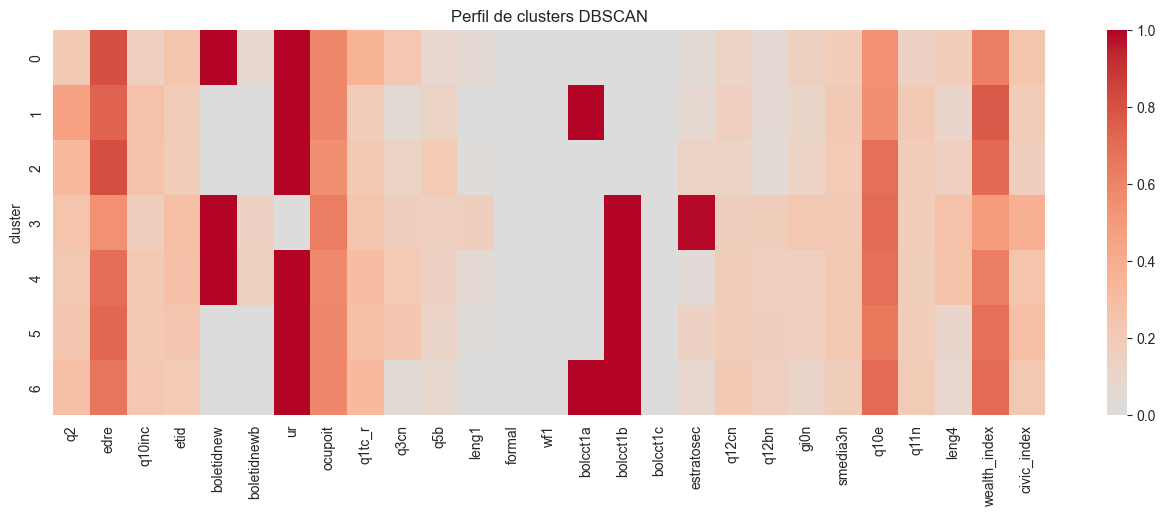

In [52]:
print("\n--- PERFIL SOCIOPOLÍTICO DE CLUSTERS ---\n")

def analizar_clusters(df_original, labels, nombre_algoritmo):
    
    df_analysis = df_original.copy()
    df_analysis['cluster'] = labels
    
    # eliminar ruido si es DBSCAN
    df_analysis = df_analysis[df_analysis['cluster'] != -1]
    
    print(f"\n===== {nombre_algoritmo} =====")
    
    resumen = df_analysis.groupby('cluster').mean()
    
    print("\nMedia de variables por cluster:")
    print(resumen.round(3))
    
    print("\nTamaño de clusters:")
    print(df_analysis['cluster'].value_counts().sort_index())
    
    return resumen


# K-Medoids
perfil_km = analizar_clusters(
    df,
    kmedoids.labels_,
    "K-Medoids"
)

# Hierarchical
perfil_hc = analizar_clusters(
    df,
    hierarchical.labels_,
    "Hierarchical"
)

# DBSCAN (solo puntos no ruido)
perfil_db = analizar_clusters(
    df,
    dbscan.labels_,
    "DBSCAN"
)

import seaborn as sns

sns.heatmap(perfil_db, cmap="coolwarm", center=0)
plt.title("Perfil de clusters DBSCAN")
plt.show()



--- VISUALIZACIÓN DE CLUSTERS ---

Aplicando PCA para reducir a 2 dimensiones...
✓ Varianza explicada: 29.51%
  PC1: 18.56%
  PC2: 10.95%


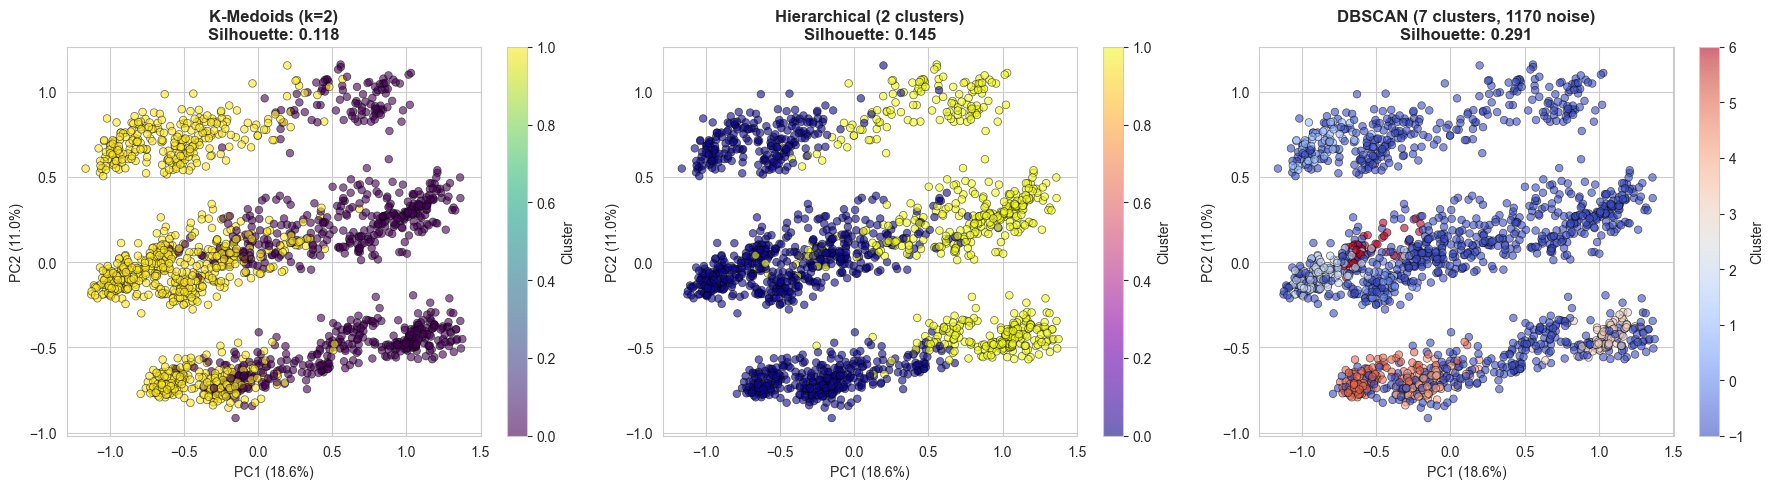


✓ Visualización guardada en: figures/comparacion_clusters_2d.png


In [53]:
print("\n--- VISUALIZACIÓN DE CLUSTERS ---\n")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 5)

# Reducir dimensionalidad a 2D con PCA
print("Aplicando PCA para reducir a 2 dimensiones...")
pca = PCA(n_components=2, random_state=42)
df_2d = pca.fit_transform(df)

print(f"✓ Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ====== K-Medoids ======
scatter1 = axes[0].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=kmedoids.labels_, 
    cmap='viridis', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_title(f'K-Medoids (k={kmedoids.n_clusters_})\nSilhouette: {metrics_km["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# ====== Hierarchical ======
scatter2 = axes[1].scatter(
    df_2d[:, 0], 
    df_2d[:, 1], 
    c=hierarchical.labels_, 
    cmap='plasma', 
    alpha=0.6,
    s=30,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_title(f'Hierarchical ({hierarchical.n_clusters_} clusters)\nSilhouette: {metrics_hc["silhouette"]:.3f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# ====== DBSCAN ======
if dbscan.n_clusters_ >= 2:
    # DBSCAN con clusters válidos
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c=dbscan.labels_, 
        cmap='coolwarm', 
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN ({dbscan.n_clusters_} clusters, {dbscan.n_noise_points_} noise)\nSilhouette: {metrics_db["silhouette"]:.3f}'
else:
    # DBSCAN sin clusters (todo ruido)
    scatter3 = axes[2].scatter(
        df_2d[:, 0], 
        df_2d[:, 1], 
        c='gray', 
        alpha=0.3,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    title = f'DBSCAN (Sin clusters)\nTodos los puntos = ruido'

axes[2].set_title(title, fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
if dbscan.n_clusters_ >= 2:
    plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.savefig('../../figures/comparacion_clusters_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada en: figures/comparacion_clusters_2d.png")
print("="*70)